In [22]:
from pathlib import Path
from collections import Counter
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

random.seed(42)


In [23]:
DATA_ROOT = Path("../src/data/brisc2025/classification_task")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

CLASSES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

In [24]:
for split_dir in [TRAIN_DIR, TEST_DIR]:
    assert split_dir.exists(), f"Nie znaleziono folderu: {split_dir}"
    for cls in CLASSES:
        cls_dir = split_dir / cls
        assert cls_dir.exists(), f"Nie znaleziono folderu: {cls_dir}"
print("gitmajonez")

gitmajonez


In [25]:
def count_files_per_class(split_dir: Path, classes: list[str]) -> dict[str, int]:
    counts = {}
    for cls in classes:
        cls_dir = split_dir / cls
        files = [f for f in cls_dir.iterdir() if f.suffix.lower() in {".jpg", ".png", ".jpeg"}]
        counts[cls] = len(files)
    return counts

train_counts = count_files_per_class(TRAIN_DIR, CLASSES)
test_counts = count_files_per_class(TEST_DIR, CLASSES)

In [26]:
summary = pd.DataFrame.from_dict({"train": train_counts, "test": test_counts})
summary['total'] = summary['train'] + summary['test']
summary.loc["TOTAL"] = summary.sum()

summary

,train,test,total
glioma,1147,254,1401
meningioma,1329,306,1635
no_tumor,1067,140,1207
pituitary,1457,300,1757
TOTAL,5000,1000,6000


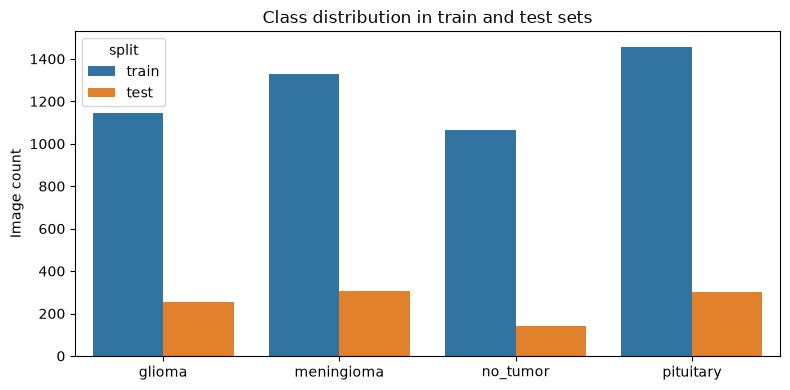

In [27]:
plot_df = summary.loc[CLASSES, ["train", "test"]].reset_index()
plot_df = plot_df.melt(id_vars="index", var_name="split", value_name="count")
plot_df = plot_df.rename(columns={"index": "class"})

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="class", y="count", hue="split")
plt.title("Class distribution in train and test sets")
plt.ylabel("Image count")
plt.xlabel("")
plt.tight_layout()
plt.show()

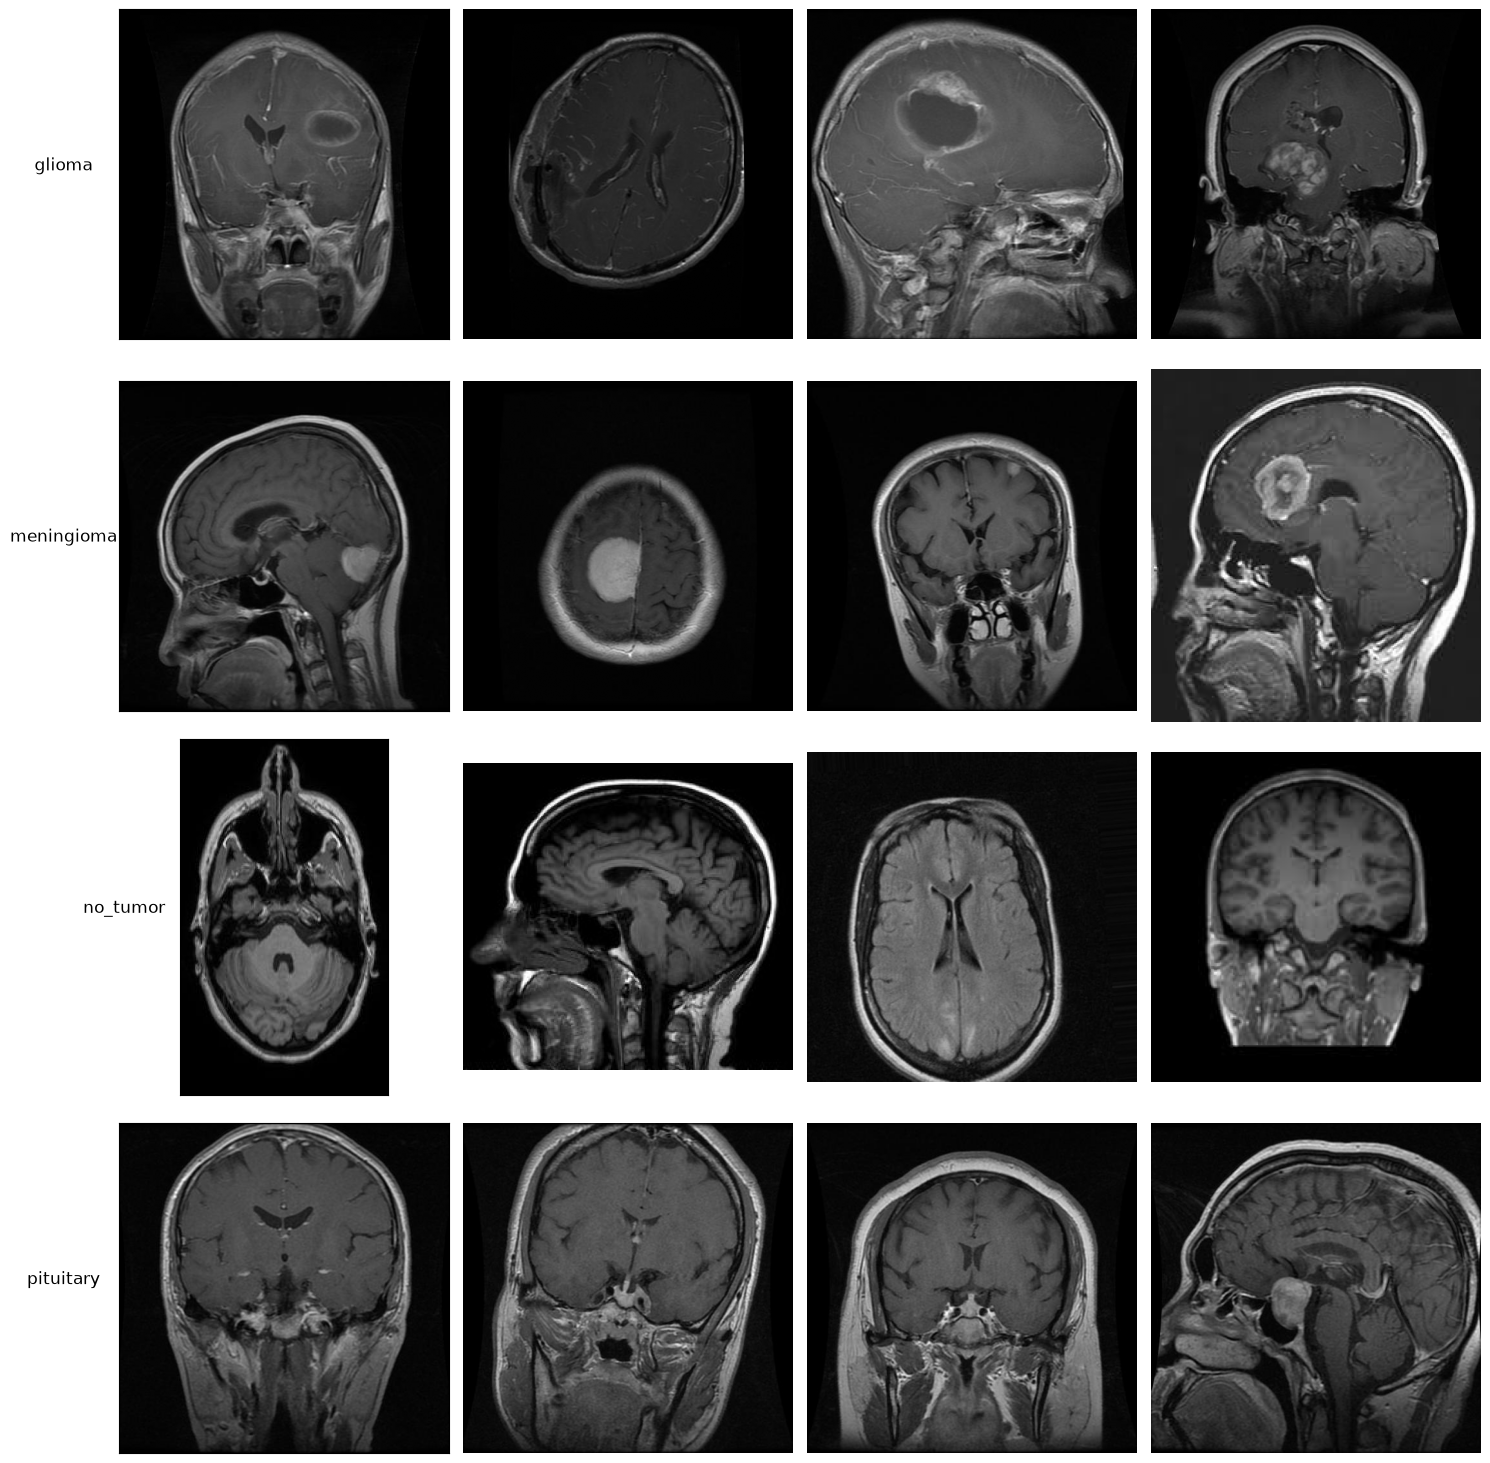

In [36]:
from matplotlib.cm import grey


fig, axes = plt.subplots(4,4,figsize=(15,15))
for i, cls in enumerate(CLASSES):
    cls_dir =  TRAIN_DIR / cls
    files = [f for f in cls_dir.iterdir() if f.suffix.lower() in {".jpg", ".png", ".jpeg"}]
    for j in range(4):
        img = Image.open(files[j])
        ax = axes[i,j]
        ax.imshow(img, cmap=grey)
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(cls, rotation=0, labelpad=40, fontsize=12)
            ax.axis("on")
            ax.set_xticks([])
            ax.set_yticks([])
plt.tight_layout()
plt.show()

In [38]:

for i, cls in enumerate(CLASSES):
    cls_dir = TRAIN_DIR / cls
    files = [f for f in cls_dir.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    random_sample = random.sample(files, 300)
    sizes = {}
    for img_path in random_sample:
        img = Image.open(img_path)
        key = str(img.size)
        if key not in sizes.keys():
            sizes[key] = 1
        else:
            sizes[key] = sizes[key] + 1
    
    print(f"Class: {cls} - {sizes}")



Class: glioma - {'(512, 512)': 300}
Class: meningioma - {'(512, 512)': 275, '(341, 372)': 1, '(367, 395)': 1, '(291, 340)': 1, '(200, 223)': 1, '(306, 306)': 1, '(300, 359)': 1, '(208, 243)': 1, '(256, 256)': 1, '(254, 325)': 1, '(513, 522)': 1, '(366, 395)': 1, '(250, 270)': 1, '(210, 240)': 1, '(552, 527)': 1, '(420, 264)': 1, '(225, 225)': 2, '(290, 342)': 1, '(298, 354)': 1, '(369, 398)': 1, '(224, 219)': 1, '(825, 993)': 1, '(262, 308)': 1, '(212, 238)': 1, '(630, 423)': 1}
Class: no_tumor - {'(1024, 1024)': 1, '(187, 369)': 6, '(512, 512)': 108, '(369, 369)': 93, '(216, 369)': 74, '(236, 294)': 1, '(236, 226)': 1, '(236, 240)': 1, '(202, 369)': 4, '(210, 369)': 1, '(236, 280)': 1, '(230, 235)': 1, '(652, 600)': 1, '(236, 236)': 1, '(237, 248)': 1, '(278, 280)': 1, '(225, 225)': 1, '(456, 501)': 1, '(236, 220)': 1, '(224, 223)': 1}
Class: pituitary - {'(512, 512)': 291, '(256, 256)': 7, '(400, 400)': 1, '(502, 502)': 1}


In [42]:
views = ['ax', 'co', 'sa']
def count_files_per_view(split_dir, classes):
    counts = {}
    for cls in classes:
        count_view = {view: 0 for view in views}
        cls_dir = split_dir / cls
        for f in cls_dir.iterdir():
            name = f.stem.lower()
            for view in views:
                if view in name:
                    count_view[view] += 1
        counts[cls] = count_view
    return counts

train_view_counts = count_files_per_view(TRAIN_DIR, CLASSES)
test_view_counts = count_files_per_view(TEST_DIR, CLASSES)


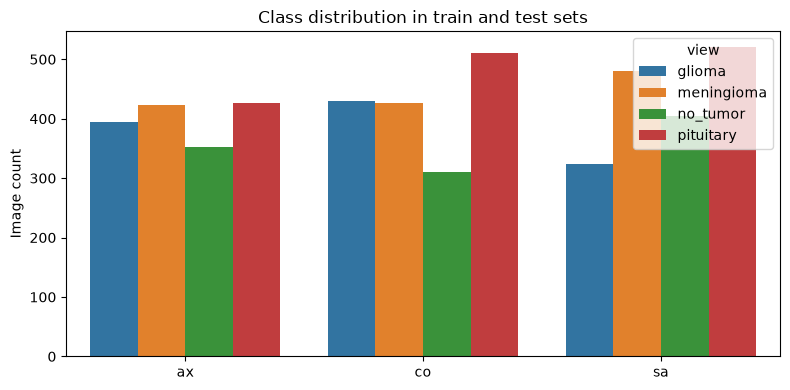

,glioma,meningioma,no_tumor,pituitary
ax,394,423,352,426
co,430,426,310,510
sa,323,480,405,521


In [52]:
summary_view_train = pd.DataFrame.from_dict(train_view_counts)

plot_df = summary_view_train.loc[views, CLASSES].reset_index()
plot_df = plot_df.melt(id_vars="index", var_name="view", value_name="count")
plot_df = plot_df.rename(columns={"index": "class"})

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="class", y="count", hue="view")
plt.title("Class distribution in train and test sets")
plt.ylabel("Image count")
plt.xlabel("")
plt.tight_layout()
plt.show()
summary_view_train